In [1]:
import pandas as pd

print("hello world")
raw_path = "cyber-threat-intelligence_all.csv"
raw = pd.read_csv(raw_path)

print("RAW shape:", raw.shape)
print("RAW columns:", list(raw.columns))
raw.head(10)

hello world
RAW shape: (19940, 10)
RAW columns: ['Unnamed: 0', 'index', 'text', 'entities', 'relations', 'Comments', 'id', 'label', 'start_offset', 'end_offset']


,Unnamed: 0,index,text,entities,relations,Comments,id,label,start_offset,end_offset
0,0,1.0,This post is also available in: 日本語 (Japa...,"[{'id': 45800, 'label': 'malware', 'start_offs...",[],[],45800.0,malware,288.0,300.0
1,1,2.0,The attack vector is very basic and repeats it...,"[{'id': 48941, 'label': 'attack-pattern', 'sta...",[],[],48941.0,attack-pattern,69.0,115.0
2,2,3.0,Once executed by the user the first stage malw...,[],[],[],NaN,NaN,NaN,NaN
3,3,4.0,The first known campaign was launched by Crim...,"[{'id': 45806, 'label': 'TIME', 'start_offset'...",[],[],45806.0,TIME,55.0,68.0
4,4,5.0,The first stage downloaded the ransomware from...,[],[],[],NaN,NaN,NaN,NaN
5,5,6.0,A very serious campaign was launched between ...,"[{'id': 22, 'label': 'identity', 'start_offset...",[],[],22.0,identity,90.0,108.0
6,6,7.0,The attacker used a polymorphic malware builde...,[],[],[],NaN,NaN,NaN,NaN
7,7,8.0,This tactic is a nightmare for legacy security...,[],[],[],NaN,NaN,NaN,NaN
8,8,9.0,Palo Alto Networks Enterprise Security Platfo...,"[{'id': 31, 'label': 'identity', 'start_offset...",[],[],31.0,identity,1.0,19.0
9,9,10.0,We can see here that server hostnames were ch...,"[{'id': 45807, 'label': 'SOFTWARE', 'start_off...",[],[],45807.0,SOFTWARE,175.0,185.0


In [21]:
print("\nMissing values per column:")
print(raw.isna().sum().sort_values(ascending=False))

print("\nNumber of duplicated rows:", raw.duplicated().sum())

# Duplicates by text only (useful in NLP)
if "text" in raw.columns:
    print("Duplicated 'text' rows:", raw.duplicated(subset=["text"]).sum())



Missing values per column:
end_offset      10478
start_offset    10478
id              10478
label           10002
relations         476
index             476
entities          476
Comments          476
Unnamed: 0          0
text                0
dtype: int64

Number of duplicated rows: 74
Duplicated 'text' rows: 11672


In [22]:
raw[["text", "label"]].head(10)


,text,label
0,This post is also available in: 日本語 (Japa...,malware
1,The attack vector is very basic and repeats it...,attack-pattern
2,Once executed by the user the first stage malw...,NaN
3,The first known campaign was launched by Crim...,TIME
4,The first stage downloaded the ransomware from...,NaN
5,A very serious campaign was launched between ...,identity
6,The attacker used a polymorphic malware builde...,NaN
7,This tactic is a nightmare for legacy security...,NaN
8,Palo Alto Networks Enterprise Security Platfo...,identity
9,We can see here that server hostnames were ch...,SOFTWARE


In [23]:
clean = raw.copy()

# Keep only usable samples
clean = clean.dropna(subset=["text", "label"]).copy()
clean["text"] = clean["text"].astype(str).str.strip()
clean["label"] = clean["label"].astype(str).str.strip()

# Remove empty text
clean = clean[clean["text"].str.len() > 0].copy()

# Optional: remove exact duplicated text
clean = clean.drop_duplicates(subset=["text"]).copy()

print("CLEAN shape:", clean.shape)
clean.head(5)


CLEAN shape: (4184, 10)


,Unnamed: 0,index,text,entities,relations,Comments,id,label,start_offset,end_offset
0,0,1.0,This post is also available in: 日本語 (Japa...,"[{'id': 45800, 'label': 'malware', 'start_offs...",[],[],45800.0,malware,288.0,300.0
1,1,2.0,The attack vector is very basic and repeats it...,"[{'id': 48941, 'label': 'attack-pattern', 'sta...",[],[],48941.0,attack-pattern,69.0,115.0
3,3,4.0,The first known campaign was launched by Crime...,"[{'id': 45806, 'label': 'TIME', 'start_offset'...",[],[],45806.0,TIME,55.0,68.0
5,5,6.0,A very serious campaign was launched between J...,"[{'id': 22, 'label': 'identity', 'start_offset...",[],[],22.0,identity,90.0,108.0
8,8,9.0,Palo Alto Networks Enterprise Security Platfor...,"[{'id': 31, 'label': 'identity', 'start_offset...",[],[],31.0,identity,1.0,19.0


In [ ]:
counts = clean["label"].value_counts()
print("Number of classes:", counts.shape[0])
counts.head(10)


Number of classes: 20


label
malware           814
SOFTWARE          572
location          514
identity          499
attack-pattern    487
threat-actor      357
TIME              222
tools             168
FILEPATH          148
vulnerability     105
Name: count, dtype: int64

In [25]:
import pandas as pd

train = pd.read_csv("cyber-threat-intelligence-splited_train.csv").dropna(subset=["text","label"])
val   = pd.read_csv("cyber-threat-intelligence-splited_validate.csv").dropna(subset=["text","label"])
test  = pd.read_csv("cyber-threat-intelligence-splited_test.csv").dropna(subset=["text","label"])

# sécurité
for df in (train, val, test):
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(str)

print("Shapes:", train.shape, val.shape, test.shape)
print("Nb classes:", train["label"].nunique())


Shapes: (3352, 10) (655, 10) (724, 10)
Nb classes: 20


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

train_path = "cyber-threat-intelligence-splited_train.csv"
train = pd.read_csv(train_path).dropna(subset=["text", "label"]).copy()
train["text"] = train["text"].astype(str)
train["label"] = train["label"].astype(str)

print("Train shape:", train.shape)
train[["text", "label"]].head(5)


Train shape: (3352, 10)


,text,label
0,"Malicious version of My First APP, which adds ...",malware
1,HYPERSCRAPE demonstrates Charming Kitten’s com...,threat-actor
5,We have evidence that the routers of at least ...,malware
11,The first known campaign was launched by Crim...,TIME
13,The TSSL project has 64-bit version.,identity


In [27]:
top10 = train["label"].value_counts().head(10)
top10


label
malware           636
location          503
attack-pattern    422
SOFTWARE          411
identity          393
threat-actor      282
TIME              170
tools             132
FILEPATH          106
vulnerability      73
Name: count, dtype: int64

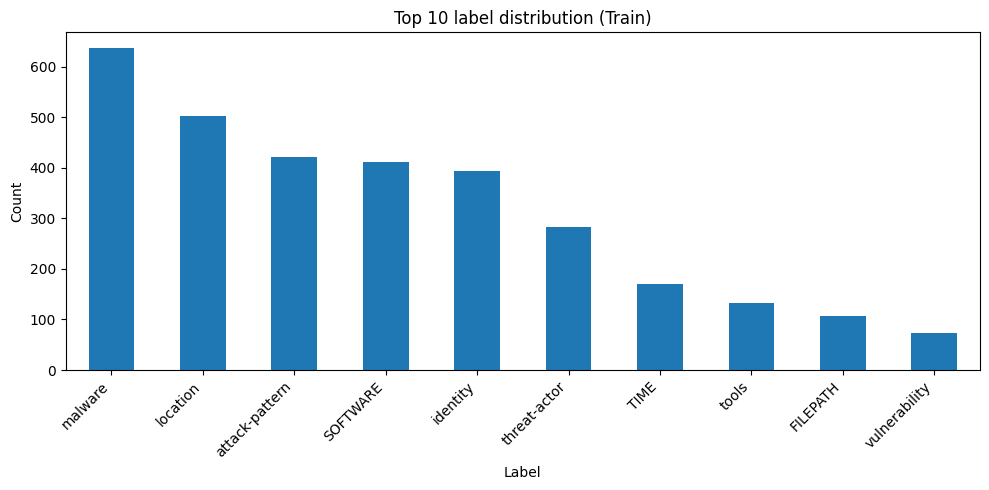

In [28]:
plt.figure(figsize=(10, 5))
top10.plot(kind="bar")
plt.title("Top 10 label distribution (Train)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

models = {
    "LR": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=30000)),
        ("clf", LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced", n_jobs=-1))
    ]),
    "LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=30000)),
        ("clf", LinearSVC(class_weight="balanced"))
    ]),
    "NB": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=30000)),
        ("clf", MultinomialNB())
    ])
}


In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def eval_on(df, model, name="model"):
    pred = model.predict(df["text"])
    acc = accuracy_score(df["label"], pred)
    f1w = f1_score(df["label"], pred, average="weighted")
    f1m = f1_score(df["label"], pred, average="macro")
    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("F1-weighted:", round(f1w, 4))
    print("F1-macro:", round(f1m, 4))
    return acc, f1w, f1m

# Fit sur train, évalue sur val
results = {}
for name, model in models.items():
    model.fit(train["text"], train["label"])
    results[name] = eval_on(val, model, name=f"{name} (VAL)")


/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== LR (VAL) ===
Accuracy: 0.4672
F1-weighted: 0.4749
F1-macro: 0.3604

=== LinearSVC (VAL) ===
Accuracy: 0.5344
F1-weighted: 0.5363
F1-macro: 0.4615

=== NB (VAL) ===
Accuracy: 0.4122
F1-weighted: 0.358
F1-macro: 0.1455


In [12]:
import numpy as np
from sklearn.model_selection import GridSearchCV, PredefinedSplit

X_trainval = pd.concat([train["text"], val["text"]], axis=0).reset_index(drop=True)
y_trainval = pd.concat([train["label"], val["label"]], axis=0).reset_index(drop=True)

test_fold = np.r_[-np.ones(len(train), dtype=int), np.zeros(len(val), dtype=int)]
ps = PredefinedSplit(test_fold)

pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced", n_jobs=-1))
])

param_grid_lr = {
    "tfidf__max_features": [20000, 30000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 3, 5],
    "tfidf__max_df": [0.7, 0.9, 1.0],
    "clf__C": [0.1, 1, 10],
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid_lr,
    scoring="f1_weighted",
    cv=ps,
    n_jobs=-1
)

grid_lr.fit(X_trainval, y_trainval)

print("\n=== GRID SEARCH LR ===")
print("Best params:", grid_lr.best_params_)
print("Best VAL f1_weighted:", round(grid_lr.best_score_, 4))

best_model = grid_lr.best_estimator_



/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site


=== GRID SEARCH LR ===
Best params: {'clf__C': 10, 'tfidf__max_df': 0.9, 'tfidf__max_features': 30000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best VAL f1_weighted: 0.5632


/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [13]:
# Refit sur train+val puis test
best_model.fit(X_trainval, y_trainval)

print("\n=== FINAL TEST (Best LR) ===")
eval_on(test, best_model, name="Best LR (TEST)")

print("\nClassification report (TEST):")
test_pred = best_model.predict(test["text"])
print(classification_report(test["label"], test_pred, zero_division=0))



=== FINAL TEST (Best LR) ===

=== Best LR (TEST) ===
Accuracy: 0.5249
F1-weighted: 0.5334
F1-macro: 0.424

Classification report (TEST):
                precision    recall  f1-score   support

        DOMAIN       0.25      0.33      0.29         3
         EMAIL       1.00      0.50      0.67         4
      FILEPATH       0.47      0.38      0.42        24
          IPV4       0.00      0.00      0.00         4
 Infrastucture       0.33      0.50      0.40         2
           MD5       0.00      0.00      0.00         1
   REGISTRYKEY       0.50      1.00      0.67         2
          SHA1       0.07      0.75      0.12         4
          SHA2       0.00      0.00      0.00        23
      SOFTWARE       0.57      0.62      0.59       104
          TIME       0.62      0.56      0.59        36
           URL       0.50      0.33      0.40         9
attack-pattern       0.62      0.54      0.58        80
      campaign       0.56      0.71      0.62         7
      identity       

/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [14]:
from sklearn.ensemble import VotingClassifier

# estimators doivent être "des modèles", pas des pipelines identiques.
# Ici on fait 3 pipelines différents.
lr = models["LR"]
svm = models["LinearSVC"]
nb  = models["NB"]

voting = VotingClassifier(
    estimators=[("lr", lr), ("svm", svm), ("nb", nb)],
    voting="hard"
)

voting.fit(train["text"], train["label"])
eval_on(val, voting, name="Voting (VAL)")

# si tu veux le test final, refit sur train+val
voting.fit(X_trainval, y_trainval)
eval_on(test, voting, name="Voting (TEST)")


/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Voting (VAL) ===
Accuracy: 0.516
F1-weighted: 0.519
F1-macro: 0.4448


/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Voting (TEST) ===
Accuracy: 0.5083
F1-weighted: 0.5268
F1-macro: 0.4109


(0.5082872928176796, 0.5267658541712671, 0.4109108817999946)

In [15]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

pipe_svc = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(class_weight="balanced"))
])

param_grid_svc = {
    "tfidf__max_features": [20000, 30000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 3, 5],
    "tfidf__max_df": [0.7, 0.9, 1.0],
    "clf__C": [0.1, 1, 10],
}

grid_svc = GridSearchCV(
    pipe_svc,
    param_grid=param_grid_svc,
    scoring="f1_weighted",
    cv=ps,      # ton PredefinedSplit train/val
    n_jobs=-1
)

grid_svc.fit(X_trainval, y_trainval)
print("Best SVC params:", grid_svc.best_params_)
print("Best SVC VAL f1_weighted:", grid_svc.best_score_)


/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/sk4lllll/Documents/Cours A4/ML-Cyber-Threat-Detection/venv/lib/python3.13/site-packages/sklearn/svm/_b

Best SVC params: {'clf__C': 1, 'tfidf__max_df': 0.7, 'tfidf__max_features': 30000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best SVC VAL f1_weighted: 0.5610777626193119


In [16]:
best_svc = grid_svc.best_estimator_   # si ton objet s'appelle grid_svc
# ou best_svc = grid.best_estimator_ si tu l'as appelé autrement

best_svc.fit(X_trainval, y_trainval)

from sklearn.metrics import accuracy_score, f1_score, classification_report

test_pred = best_svc.predict(test["text"])
print("=== FINAL TEST (Best SVC) ===")
print("Test Accuracy:", round(accuracy_score(test["label"], test_pred), 4))
print("Test F1-weighted:", round(f1_score(test["label"], test_pred, average="weighted"), 4))
print("Test F1-macro:", round(f1_score(test["label"], test_pred, average="macro"), 4))
print("\nClassification report:\n")
print(classification_report(test["label"], test_pred, zero_division=0))


=== FINAL TEST (Best SVC) ===
Test Accuracy: 0.576
Test F1-weighted: 0.5745
Test F1-macro: 0.5096

Classification report:

                precision    recall  f1-score   support

        DOMAIN       0.33      0.33      0.33         3
         EMAIL       0.75      0.75      0.75         4
      FILEPATH       0.46      0.54      0.50        24
          IPV4       0.25      0.25      0.25         4
 Infrastucture       0.50      0.50      0.50         2
           MD5       0.00      0.00      0.00         1
   REGISTRYKEY       0.50      1.00      0.67         2
          SHA1       0.43      0.75      0.55         4
          SHA2       0.53      0.39      0.45        23
      SOFTWARE       0.56      0.60      0.58       104
          TIME       0.48      0.56      0.51        36
           URL       0.50      0.56      0.53         9
attack-pattern       0.63      0.61      0.62        80
      campaign       0.60      0.86      0.71         7
      identity       0.59      0.65 

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

tree_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000)),
    ("clf", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(train["text"], train["label"])
eval_on(val, tree_model, name="DecisionTree (VAL)")



=== DecisionTree (VAL) ===
Accuracy: 0.4092
F1-weighted: 0.41
F1-macro: 0.322


(0.40916030534351144, 0.40997561875242927, 0.32201056302091446)